In [4]:
# GET DEVICE
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

torch.inference_mode().__enter__()

using device: cpu


In [5]:
# UTIL
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='.', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='.', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [6]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

sam2_checkpoint = "./checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)

predictor = SAM2ImagePredictor(sam2_model)

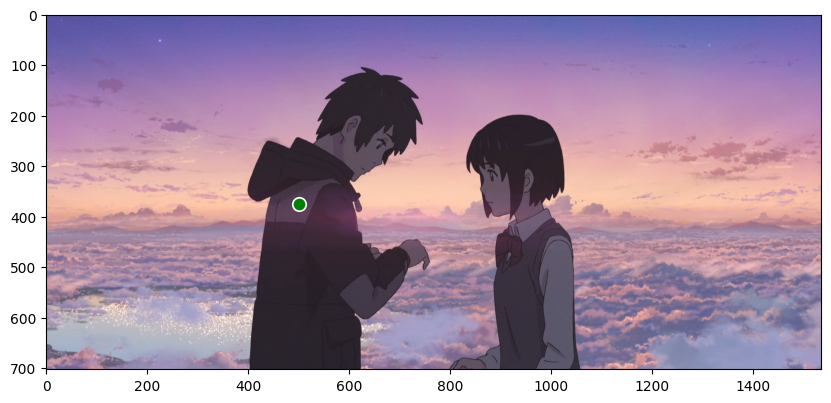

In [7]:
image = Image.open('example.png')
image = np.array(image.convert("RGB"))

predictor.set_image(image)

input_point = np.array([[500, 375]]) # point of interest
input_label = np.array([1]) # 1 is foreground, 0 is background

plt.figure(figsize=(10, 10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()

# small is: 13s
# large is: 40s
# tiny is: 8s

# local: 2.6s!!

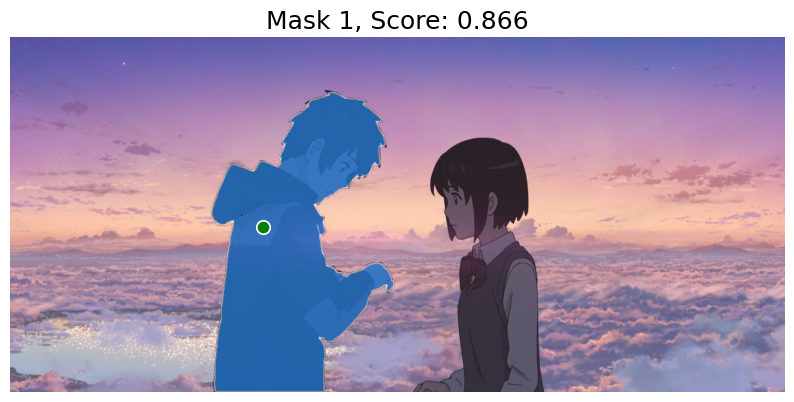

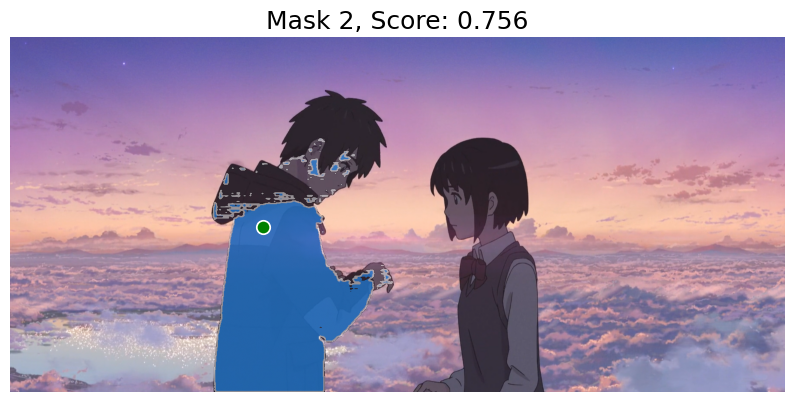

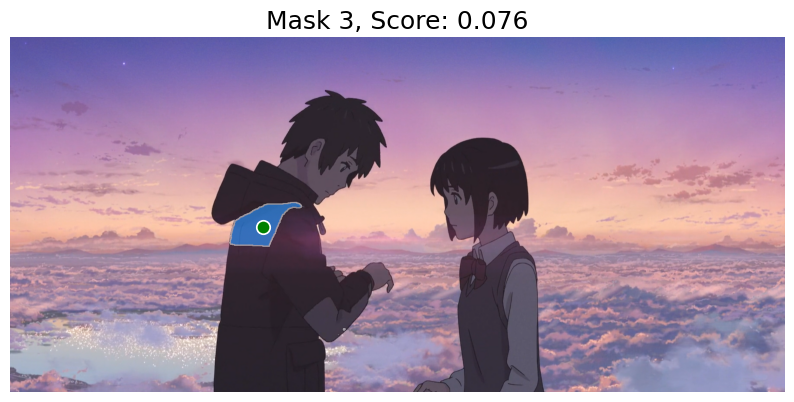

In [7]:
masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind] # ignore this (scores but raw)

show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=True)

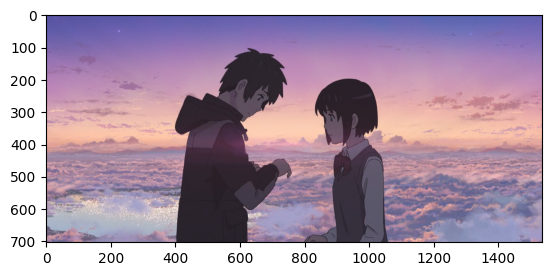

In [9]:
plt.imshow(image)

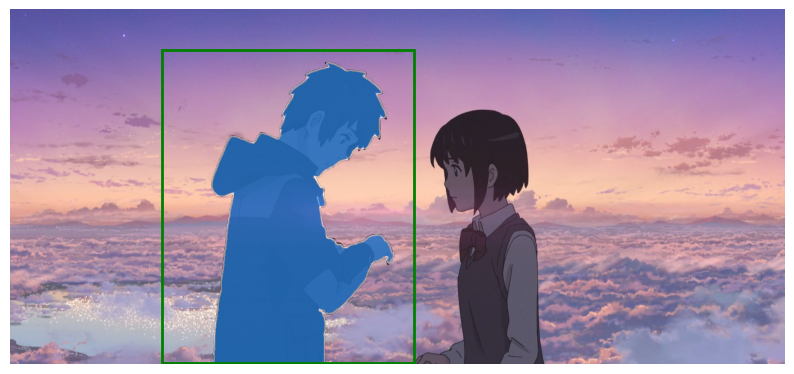

In [11]:
def get_mask(x1, y1, x2, y2):
  box = np.array([x1, y1, x2, y2])
  masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=box[None, :], # add one dimension
    multimask_output=False,
  )

  return masks, scores, box

masks, scores, input_box = get_mask(300, 80, 800, 700)

show_masks(image, masks, scores, box_coords=input_box)

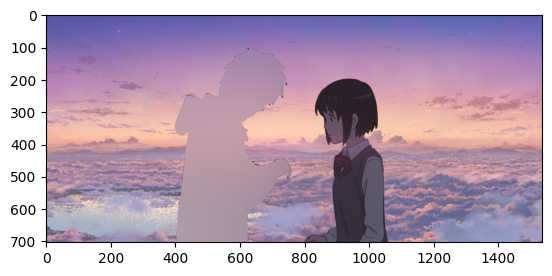

In [12]:
# Inpaint
import cv2

image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
mask_uint8 = (masks[0] == 1).astype(np.uint8) * 255

# Basic inpaint
inpainted = cv2.inpaint(image_bgr, mask_uint8, 5, cv2.INPAINT_TELEA)

# Apply extreme blur
blurred = inpainted
for i in range(3):
    blurred = cv2.GaussianBlur(blurred, (511, 511), 0)

# Blend back only the masked region
result = image_bgr.copy()
result[mask_uint8 == 255] = blurred[mask_uint8 == 255]

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.imshow(result_rgb)

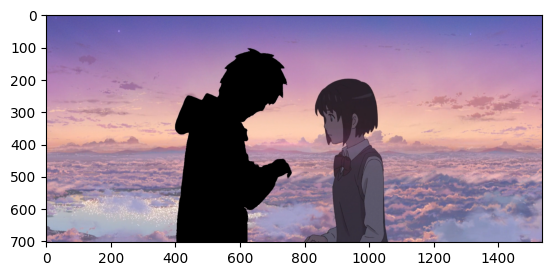

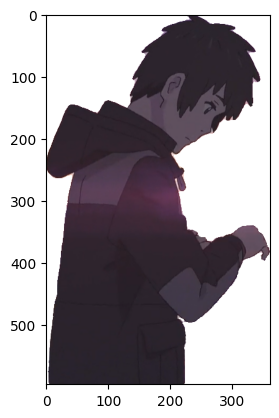

In [ ]:
def take_sticker(x1, y1, x2, y2):
    """ Reuse predictor.set_image """
    box = np.array([x1, y1, x2, y2])
    masks, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=box[None, :], # add one dimension
        multimask_output=False,
    )
    
    mask = masks[0]

    out_im = image.copy()
    out_im[mask == 1] = [0, 0, 0]
    
    # Create Sticker
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    cropped_rgb = image[rmin:rmax+1, cmin:cmax+1]
    cropped_mask = mask[rmin:rmax+1, cmin:cmax+1]

    # RGBA: transparent where mask is False
    h, w = cropped_rgb.shape[:2]
    sticker = np.zeros((h, w, 4), dtype=np.uint8)
    sticker[..., :3] = cropped_rgb
    sticker[..., 3] = cropped_mask.astype(np.uint8) * 255


    return out_im, sticker

x, y = take_sticker(300, 80, 800, 700)
plt.imshow(x)
plt.figure()
plt.imshow(y)

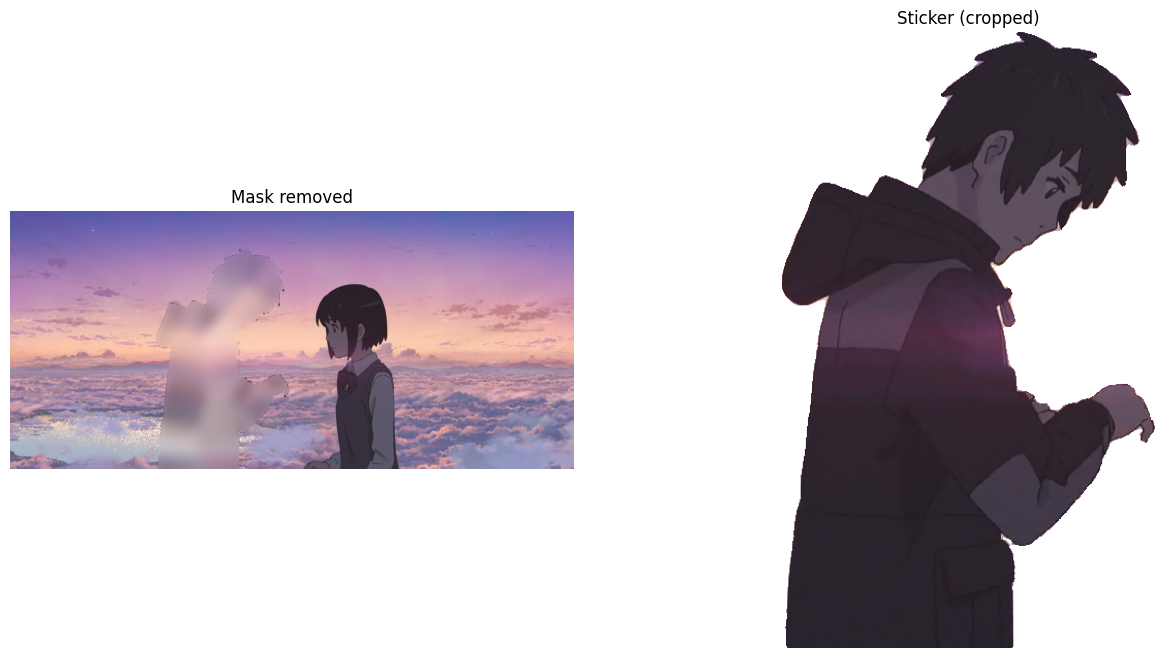

In [28]:
def take_sticker_and_blur(image, x1, y1, x2, y2):
    box = np.array([x1, y1, x2, y2])
    masks, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=box[None, :],
        multimask_output=False,
    )

    mask = masks[0]  # (H, W) bool
    mask_uint8 = mask.astype(np.uint8) * 255

    # --- Image 1: mask removed (inpainted + blurred) ---
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    inpainted = cv2.inpaint(image_bgr, mask_uint8, 5, cv2.INPAINT_TELEA)
    blurred = inpainted
    blurred = cv2.GaussianBlur(blurred, (101, 101), 0)
    # for _ in range(3):
    #     blurred = cv2.GaussianBlur(blurred, (511, 511), 0)
    result = image_bgr.copy()
    result[mask_uint8 == 255] = blurred[mask_uint8 == 255]
    image_without_mask = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

    # --- Image 2: only the mask, tightly cropped with transparency ---
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    cropped_rgb = image[rmin:rmax+1, cmin:cmax+1]
    cropped_mask = mask[rmin:rmax+1, cmin:cmax+1]

    # RGBA: transparent where mask is False
    h, w = cropped_rgb.shape[:2]
    sticker = np.zeros((h, w, 4), dtype=np.uint8)
    sticker[..., :3] = cropped_rgb
    sticker[..., 3] = cropped_mask.astype(np.uint8) * 255

    return image_without_mask, sticker

image_without_mask, sticker = take_sticker_and_blur(image, 300, 80, 800, 700)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(image_without_mask)
axes[0].set_title("Mask removed")
axes[0].axis('off')
axes[1].imshow(sticker)
axes[1].set_title("Sticker (cropped)")
axes[1].axis('off')
plt.show()


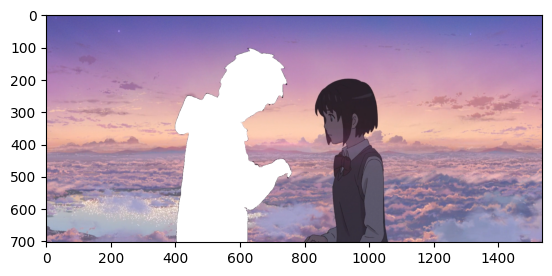

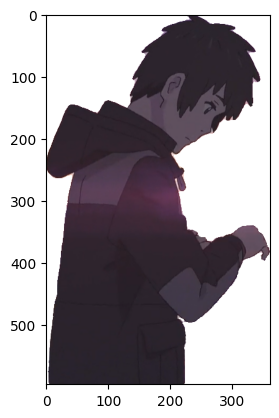

In [8]:
def take_sticker_transparent(x1, y1, x2, y2):
    """ Reuse predictor.set_image """
    box = np.array([x1, y1, x2, y2])
    masks, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=box[None, :], # add one dimension
        multimask_output=False,
    )
    
    mask = masks[0]
    
    out_im = np.dstack([image, np.full(image.shape[:2], 255, dtype=np.uint8)])
    out_im[mask == 1, 3] = 0
    
    # Create Sticker
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    cropped_rgb = image[rmin:rmax+1, cmin:cmax+1]
    cropped_mask = mask[rmin:rmax+1, cmin:cmax+1]

    # RGBA: transparent where mask is False
    h, w = cropped_rgb.shape[:2]
    sticker = np.zeros((h, w, 4), dtype=np.uint8)
    sticker[..., :3] = cropped_rgb
    sticker[..., 3] = cropped_mask.astype(np.uint8) * 255


    return out_im, sticker

x, y = take_sticker_transparent(300, 80, 800, 700)
plt.imshow(x)
plt.figure()
plt.imshow(y)